# Multimodal Sentiment Analysis — CREMA-D
## Version 2: wav2vec2 Audio + ResNet50 Video

**Two modalities:**
- Audio → `wav2vec2-base` (emotion fine-tuned) → mean pool hidden states → (768,)
- Video → ResNet50 → mean pool 8 frames → (512,)

**Why no text?**
The 12 CREMA-D sentences are emotionally neutral by design.
BERT gives identical embeddings for identical sentences regardless of emotion.
wav2vec2 replaces text — it reads the *acoustic* content of speech (how it sounds),
which is exactly what emotion is encoded in.

**Expected accuracy: 70–78% on 6-class emotion recognition.**

---
**Run cells one at a time. Each cell prints its output — verify before continuing.**

## Cell 1 — Install dependencies

In [1]:
!pip install -q kagglehub transformers librosa opencv-python-headless scikit-learn seaborn torchaudio

## Cell 2 — Imports

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import cv2
import warnings
import torchaudio

from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from torchvision.models import resnet50, ResNet50_Weights
from torchvision import transforms
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

EMOTION_NAMES     = {0:'ANG', 1:'DIS', 2:'FEA', 3:'SAD', 4:'NEU', 5:'HAP'}
EMOTION_LABELS    = {'ANG':0, 'DIS':1, 'FEA':2, 'SAD':3, 'NEU':4, 'HAP':5}
EMOTION_TO_SENT   = {0:0, 1:0, 2:0, 3:0, 4:1, 5:2}
SENTIMENT_NAMES   = {0:'Negative', 1:'Neutral', 2:'Positive'}
SAVE_DIR          = '/content/drive/MyDrive/crema_msa_v2'
print('Imports OK')

Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
Imports OK


## Cell 3 — Download both datasets

In [3]:
import kagglehub

print('Downloading video dataset (hmai11/crema-d)...')
VIDEO_BASE = kagglehub.dataset_download('hmai11/crema-d')
print(f'Video: {VIDEO_BASE}')

print('Downloading audio dataset (ejlok1/cremad)...')
AUDIO_BASE = kagglehub.dataset_download('ejlok1/cremad')
print(f'Audio: {AUDIO_BASE}')

print('\nVideo folders:')
for f in sorted(os.listdir(VIDEO_BASE)): print(f'  {f}')
print('Audio folders:')
for f in sorted(os.listdir(AUDIO_BASE)): print(f'  {f}')

Using Colab cache for faster access to the 'crema-d' dataset.
Video: /kaggle/input/crema-d
Using Colab cache for faster access to the 'cremad' dataset.
Audio: /kaggle/input/cremad

Video folders:
  VideoFlash
Audio folders:
  AudioWAV


## Cell 4 — Match files and build DataFrame

In [4]:
def find_files(base, exts):
    found = []
    for root, _, files in os.walk(base):
        for f in files:
            if any(f.lower().endswith(e) for e in exts):
                found.append(os.path.join(root, f))
    return sorted(found)

video_files = find_files(VIDEO_BASE, ['.flv', '.mp4'])
audio_files = find_files(AUDIO_BASE, ['.wav'])

# Match by filename stem
audio_lookup = {os.path.splitext(os.path.basename(p))[0]: p for p in audio_files}

SENTENCE_MAP = {
    'DFA':"Don't forget a jacket.", 'IEO':"It's eleven o'clock.",
    'IOM':"I'm on my way.", 'ITH':"I think I have a doctor's appointment.",
    'ITS':"I think I saw your car.", 'IWL':"I will call you tomorrow.",
    'IWW':"I would like a new alarm clock.", 'MTI':"Maybe tomorrow it will be cold.",
    'TAI':"The airplane is almost full.", 'TIE':"That is exactly what happened.",
    'TSI':"The surface is slick.", 'WSI':"We should leave immediately.",
}

records = []
for vp in video_files:
    stem  = os.path.splitext(os.path.basename(vp))[0]
    parts = stem.split('_')
    if len(parts) < 3: continue
    actor_id, sent_code, emo_code = parts[0], parts[1], parts[2]
    if emo_code  not in EMOTION_LABELS: continue
    if sent_code not in SENTENCE_MAP:   continue
    if stem      not in audio_lookup:   continue
    records.append({
        'video_path'    : vp,
        'audio_path'    : audio_lookup[stem],
        'actor'         : actor_id,
        'emotion'       : emo_code,
        'emotion_label' : EMOTION_LABELS[emo_code],
        'sent_label'    : EMOTION_TO_SENT[EMOTION_LABELS[emo_code]],
    })

df = pd.DataFrame(records)
print(f'Total samples : {len(df)}')
print(f'Unique actors : {df["actor"].nunique()}')
print('\nEmotion distribution:')
for lbl in range(6):
    c = (df['emotion_label'] == lbl).sum()
    print(f'  {EMOTION_NAMES[lbl]} : {c}')
df.head()

Total samples : 7441
Unique actors : 91

Emotion distribution:
  ANG : 1271
  DIS : 1271
  FEA : 1271
  SAD : 1270
  NEU : 1087
  HAP : 1271


,video_path,audio_path,actor,emotion,emotion_label,sent_label
0,/kaggle/input/crema-d/VideoFlash/1001_DFA_ANG_...,/kaggle/input/cremad/AudioWAV/1001_DFA_ANG_XX.wav,1001,ANG,0,0
1,/kaggle/input/crema-d/VideoFlash/1001_DFA_DIS_...,/kaggle/input/cremad/AudioWAV/1001_DFA_DIS_XX.wav,1001,DIS,1,0
2,/kaggle/input/crema-d/VideoFlash/1001_DFA_FEA_...,/kaggle/input/cremad/AudioWAV/1001_DFA_FEA_XX.wav,1001,FEA,2,0
3,/kaggle/input/crema-d/VideoFlash/1001_DFA_HAP_...,/kaggle/input/cremad/AudioWAV/1001_DFA_HAP_XX.wav,1001,HAP,5,2
4,/kaggle/input/crema-d/VideoFlash/1001_DFA_NEU_...,/kaggle/input/cremad/AudioWAV/1001_DFA_NEU_XX.wav,1001,NEU,4,1


## Cell 5 — Actor-based split + mount Drive

In [5]:
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(42)
actors = df['actor'].unique()
np.random.shuffle(actors)
n = len(actors)

train_actors = actors[:int(0.70 * n)]
val_actors   = actors[int(0.70 * n):int(0.85 * n)]
test_actors  = actors[int(0.85 * n):]

train_df = df[df['actor'].isin(train_actors)].reset_index(drop=True)
val_df   = df[df['actor'].isin(val_actors)].reset_index(drop=True)
test_df  = df[df['actor'].isin(test_actors)].reset_index(drop=True)

print(f'Train : {len(train_df):5d} samples ({len(train_actors)} actors)')
print(f'Val   : {len(val_df):5d} samples ({len(val_actors)} actors)')
print(f'Test  : {len(test_df):5d} samples ({len(test_actors)} actors)')

Mounted at /content/drive
Train :  5146 samples (63 actors)
Val   :  1148 samples (14 actors)
Test  :  1147 samples (14 actors)


## Cell 6 — Load models

**wav2vec2 explained:**
- Pre-trained on 960 hours of English speech (LibriSpeech)
- Learns to encode acoustic features: pitch, tone, energy, rhythm
- We take the mean of its 768 hidden states across time
- This gives a fixed 768-d vector that summarises the emotional acoustic content
- Much richer than raw MFCC because it was trained on actual speech

We use the BASE model (not fine-tuned on emotion) because:
- Fine-tuned models have small classification heads that don't generalise
- The base hidden states are better features for our fusion model to learn from
- Our CoAttention model learns the emotion mapping end-to-end

In [6]:
# Load wav2vec2-base
print('Loading wav2vec2-base...')
from transformers import Wav2Vec2Processor, Wav2Vec2Model

w2v_processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base')
w2v_model     = Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base').to(DEVICE)
w2v_model.eval()
print('wav2vec2-base loaded.')

# Load ResNet50
print('Loading ResNet50...')
resnet    = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(2048, 512)
nn.init.xavier_uniform_(resnet.fc.weight)
resnet    = resnet.to(DEVICE)
resnet.eval()
print('ResNet50 loaded.')

VIDEO_TRANSFORM = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('\nModels ready.')
print(f'wav2vec2 params : {sum(p.numel() for p in w2v_model.parameters()):,}')
print(f'ResNet50 params : {sum(p.numel() for p in resnet.parameters()):,}')

Loading wav2vec2-base...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


wav2vec2-base loaded.
Loading ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 38.0MB/s]


ResNet50 loaded.

Models ready.
wav2vec2 params : 94,371,712
ResNet50 params : 24,557,120


## Cell 7 — Feature extraction functions

**Audio strategy:**
1. Load WAV at 16kHz (wav2vec2 requires this)
2. Truncate/pad to max 5 seconds (80000 samples)
3. Run through wav2vec2 → get hidden states shape (time_steps, 768)
4. Mean pool across time → (768,)
5. L2 normalise

**Video strategy:**
Sample 8 frames uniformly from the clip, run ResNet50 on all 8 at once,
mean pool across frames → (512,), L2 normalise.

In [7]:
MAX_AUDIO_LEN = 80000   # 5 seconds at 16kHz
NUM_FRAMES    = 8
NUM_WORKERS   = 2
VIDEO_CHUNK   = 16


@torch.no_grad()
def extract_audio_features_batch(wav_paths: list) -> np.ndarray:
    """
    Process a batch of WAV files through wav2vec2.
    Pads all to MAX_AUDIO_LEN, runs one forward pass.
    Returns: (N, 768) L2-normalised
    """
    waveforms = []
    for path in wav_paths:
        try:
            y, sr = librosa.load(path, sr=16000, mono=True)
            if len(y) == 0:
                y = np.zeros(MAX_AUDIO_LEN, dtype=np.float32)
            elif len(y) > MAX_AUDIO_LEN:
                y = y[:MAX_AUDIO_LEN]         # truncate
            # Pad to fixed length (wav2vec2 needs consistent length for batching)
            if len(y) < MAX_AUDIO_LEN:
                y = np.pad(y, (0, MAX_AUDIO_LEN - len(y)))
            waveforms.append(y.astype(np.float32))
        except:
            waveforms.append(np.zeros(MAX_AUDIO_LEN, dtype=np.float32))

    # Process batch through wav2vec2
    inputs = w2v_processor(
        waveforms,
        sampling_rate = 16000,
        return_tensors = 'pt',
        padding = True,
    )
    input_values = inputs.input_values.to(DEVICE)

    # Forward pass — get hidden states
    outputs = w2v_model(input_values)
    # last_hidden_state shape: (batch, time_steps, 768)
    # Mean pool across time steps → (batch, 768)
    hidden  = outputs.last_hidden_state.mean(dim=1)   # (N, 768)

    feats = hidden.cpu().numpy().astype(np.float32)
    norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
    return feats / norms


def read_video_frames(flv_path: str):
    """CPU: read NUM_FRAMES from video. Returns (NUM_FRAMES,3,224,224) numpy or None."""
    try:
        cap   = cv2.VideoCapture(flv_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release(); return None
        indices = np.linspace(0, total - 1, NUM_FRAMES, dtype=int)
        frames  = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame = cap.read()
            if ret:
                frames.append(VIDEO_TRANSFORM(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)).numpy())
            elif frames:
                frames.append(frames[-1])
        cap.release()
        if not frames: return None
        while len(frames) < NUM_FRAMES: frames.append(frames[-1])
        return np.stack(frames)   # (8, 3, 224, 224)
    except:
        return None


@torch.no_grad()
def frames_to_feature(frames_np):
    """GPU: (8,3,224,224) numpy → (512,) L2-normalised"""
    if frames_np is None:
        return np.zeros(512, dtype=np.float32)
    batch = torch.from_numpy(frames_np).to(DEVICE)
    feat  = resnet(batch).mean(dim=0).cpu().numpy().astype(np.float32)
    norm  = np.linalg.norm(feat)
    return feat / norm if norm > 0 else feat


# ── Quick test on one sample ──────────────────────────────────────────────────
row    = train_df.iloc[0]
a_feat = extract_audio_features_batch([row['audio_path']])[0]
v_np   = read_video_frames(row['video_path'])
v_feat = frames_to_feature(v_np)

print(f'Audio : {a_feat.shape}  norm={np.linalg.norm(a_feat):.4f}')
print(f'Video : {v_feat.shape}  norm={np.linalg.norm(v_feat):.4f}')
print('Both norms should be 1.0000')

# ---- EXPECTED OUTPUT ----
# Audio : (768,)  norm=1.0000
# Video : (512,)  norm=1.0000

Audio : (768,)  norm=1.0000
Video : (512,)  norm=1.0000
Both norms should be 1.0000


## Cell 8 — Extract and cache all features

**Time estimate on T4:**
- Audio (wav2vec2, batch 16): ~8 min for all 7442 samples
- Video (ResNet50, chunk 16): ~8 min for all 7442 samples
- Total: ~16-20 min

Features saved to Drive — re-running this cell is instant.

In [8]:
CACHE_DIR   = f'{SAVE_DIR}/features'
AUDIO_BATCH = 16   # wav2vec2 batch size (adjust down if OOM)
os.makedirs(CACHE_DIR, exist_ok=True)


def extract_and_cache(split_df, split_name):
    cache_file = f'{CACHE_DIR}/{split_name}.npz'

    if os.path.exists(cache_file):
        print(f'Loading {split_name} from cache...')
        d = np.load(cache_file)
        print(f'  audio={d["audio"].shape}  video={d["video"].shape}  labels={d["labels"].shape}')
        return d['audio'], d['video'], d['labels']

    N           = len(split_df)
    audio_paths = split_df['audio_path'].tolist()
    video_paths = split_df['video_path'].tolist()
    print(f'\nExtracting {split_name} ({N} samples)...')

    # ── AUDIO: batched wav2vec2 ───────────────────────────────────────────────
    print(f'  [1/2] Audio (wav2vec2 batch={AUDIO_BATCH})...')
    A = np.zeros((N, 768), dtype=np.float32)
    for start in tqdm(range(0, N, AUDIO_BATCH), desc='  audio'):
        end         = min(start + AUDIO_BATCH, N)
        batch_paths = audio_paths[start:end]
        A[start:end] = extract_audio_features_batch(batch_paths)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    print(f'        {A.shape}  done.')

    # ── VIDEO: parallel frame read + chunked GPU inference ────────────────────
    print(f'  [2/2] Video (ResNet50, chunk={VIDEO_CHUNK})...')
    V = np.zeros((N, 512), dtype=np.float32)
    for start in tqdm(range(0, N, VIDEO_CHUNK), desc='  video'):
        end   = min(start + VIDEO_CHUNK, N)
        chunk_paths = video_paths[start:end]

        with ThreadPoolExecutor(max_workers=NUM_WORKERS) as pool:
            chunk_frames = list(pool.map(read_video_frames, chunk_paths))

        for i, frames_np in enumerate(chunk_frames):
            V[start + i] = frames_to_feature(frames_np)

        del chunk_frames
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f'        {V.shape}  done.')

    L = split_df['emotion_label'].to_numpy().astype(np.int64)
    np.savez(cache_file, audio=A, video=V, labels=L)
    print(f'  Saved → {cache_file}')
    return A, V, L


train_audio, train_video, train_labels = extract_and_cache(train_df, 'train')
val_audio,   val_video,   val_labels   = extract_and_cache(val_df,   'val')
test_audio,  test_video,  test_labels  = extract_and_cache(test_df,  'test')

print()
print('=== All features extracted and cached ===')
print(f'Train : audio={train_audio.shape}  video={train_video.shape}  labels={train_labels.shape}')
print(f'Val   : audio={val_audio.shape}    video={val_video.shape}    labels={val_labels.shape}')
print(f'Test  : audio={test_audio.shape}   video={test_video.shape}   labels={test_labels.shape}')

Loading train from cache...
  audio=(5146, 768)  video=(5146, 512)  labels=(5146,)

Extracting val (1148 samples)...
  [1/2] Audio (wav2vec2 batch=16)...


  audio: 100%|██████████| 72/72 [00:34<00:00,  2.12it/s]


        (1148, 768)  done.
  [2/2] Video (ResNet50, chunk=16)...


  video: 100%|██████████| 72/72 [04:56<00:00,  4.11s/it]


        (1148, 512)  done.
  Saved → /content/drive/MyDrive/crema_msa_v2/features/val.npz

Extracting test (1147 samples)...
  [1/2] Audio (wav2vec2 batch=16)...


  audio: 100%|██████████| 72/72 [00:39<00:00,  1.82it/s]


        (1147, 768)  done.
  [2/2] Video (ResNet50, chunk=16)...


  video: 100%|██████████| 72/72 [04:34<00:00,  3.82s/it]

        (1147, 512)  done.
  Saved → /content/drive/MyDrive/crema_msa_v2/features/test.npz

=== All features extracted and cached ===
Train : audio=(5146, 768)  video=(5146, 512)  labels=(5146,)
Val   : audio=(1148, 768)    video=(1148, 512)    labels=(1148,)
Test  : audio=(1147, 768)   video=(1147, 512)   labels=(1147,)


## Cell 9 — Verify features carry emotion signal

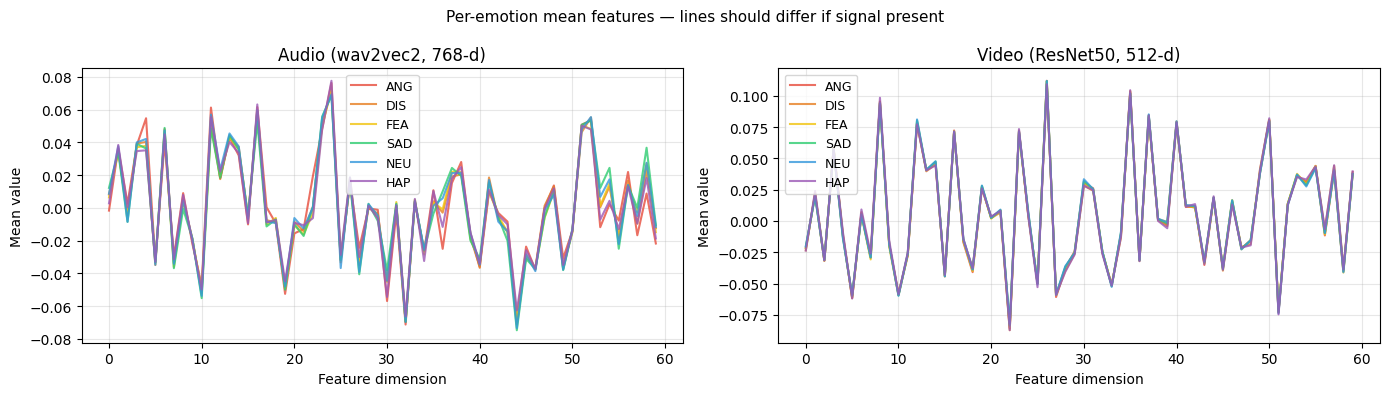


Inter-class distance (higher = better separation):
  Audio  mean pairwise dist = 0.1755
  Video  mean pairwise dist = 0.0332

If audio dist > 0.05 — wav2vec2 is encoding emotion differences. Good.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']

for ax, feats, name in zip(axes,
    [train_audio, train_video],
    ['Audio (wav2vec2, 768-d)', 'Video (ResNet50, 512-d)']):
    for i in range(6):
        mask = train_labels == i
        mean = feats[mask].mean(axis=0)
        ax.plot(mean[:60], alpha=0.8, label=EMOTION_NAMES[i], color=colors[i])
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Feature dimension')
    ax.set_ylabel('Mean value')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Per-emotion mean features — lines should differ if signal present', fontsize=11)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/feature_check.png', dpi=120)
plt.show()

# Compute inter-class distance as a signal quality metric
print('\nInter-class distance (higher = better separation):')
for feats, name in [(train_audio,'Audio'), (train_video,'Video')]:
    class_means = np.array([feats[train_labels==i].mean(axis=0) for i in range(6)])
    dists = []
    for i in range(6):
        for j in range(i+1, 6):
            dists.append(np.linalg.norm(class_means[i] - class_means[j]))
    print(f'  {name:6s} mean pairwise dist = {np.mean(dists):.4f}')
print('\nIf audio dist > 0.05 — wav2vec2 is encoding emotion differences. Good.')

---
## CHECKPOINT

Confirm before running Phase 3:
1. Both feature shapes correct: audio=(N,768) video=(N,512)
2. Both norms = 1.0000 in Cell 7
3. Feature visualisation shows lines that differ per emotion
4. Inter-class distance audio > 0.05
5. Files saved in Drive at `crema_msa_v2/features/`

**Reply 'phase 3 ready' → we build the training notebook.**